In [18]:
# import necessary libraries

import pandas as pd
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import pickle

In [19]:
# download nltk resources

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
# load training dataset

train_df = pd.read_csv(
    'train.txt',
    sep=';',
    names=['text', 'emotion'],
    header=None
)

# load validation dataset

val_df = pd.read_csv(
    'val.txt',
    sep=';',
    names=['text', 'emotion'],
    header=None
)

# load testing dataset

test_df = pd.read_csv(
    'test.txt',
    sep=';',
    names=['text', 'emotion'],
    header=None
)

In [21]:
print(train_df.head())

                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [22]:
# display dataset information

print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB
None


In [23]:
# initialize stopwords and stemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [24]:
# define text preprocessing function

def preprocess_text(text):
    text = text.lower()
    words = word_tokenize(text)
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
        and word not in string.punctuation
    ]
    return " ".join(words)

In [25]:
# apply preprocessing on all datasets

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text'] = val_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

In [26]:
# separate input and output data

X_train = train_df['clean_text']
y_train = train_df['emotion']

X_val = val_df['clean_text']
y_val = val_df['emotion']

X_test = test_df['clean_text']
y_test = test_df['emotion']

In [27]:
# convert text data into numerical form using TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized = vectorizer.transform(X_val)
X_test_vectorized = vectorizer.transform(X_test)

In [28]:
# create and train Logistic Regression model

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vectorized, y_train)

LogisticRegression(max_iter=1000)

In [29]:
# save model

with open('emotion_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# save vectorizer

with open('emotion_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print("Model and Vectorizer saved successfully")

Model and Vectorizer saved successfully


In [30]:
# predict validation data and display accuracy

y_val_pred = model.predict(X_val_vectorized)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.8425


In [31]:
# predict test data and display accuracy

y_test_pred = model.predict(X_test_vectorized)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.845


In [32]:
# display classification report

classification_rep = classification_report(y_test, y_test_pred)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

       anger       0.85      0.79      0.82       275
        fear       0.85      0.79      0.82       224
         joy       0.83      0.94      0.88       695
        love       0.77      0.54      0.63       159
     sadness       0.87      0.90      0.89       581
    surprise       0.85      0.50      0.63        66

    accuracy                           0.84      2000
   macro avg       0.84      0.74      0.78      2000
weighted avg       0.84      0.84      0.84      2000



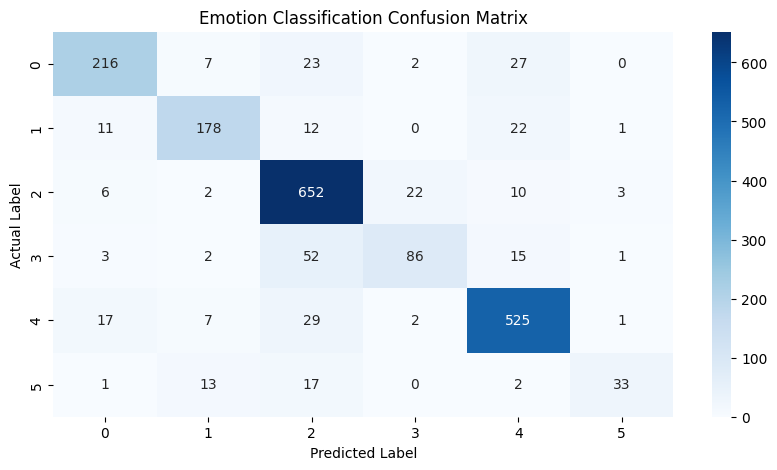

In [33]:
# create and visualize confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Emotion Classification Confusion Matrix')
plt.show()